# Wind Effects on Flight Planning

**Purpose:** Wind does not just change how long a flight takes -- it fundamentally alters the geometry of the mission. Crosswinds force the aircraft to fly with a crab angle (nose pointed into the wind to maintain the desired ground track), which rotates the sensor field of view relative to the ground track and distorts the imaged swath. Headwinds and tailwinds change groundspeed, affecting data collection timing and along-track sampling. During turns between flight lines, wind transforms the circular Dubins arcs into trochoidal curves that drift downwind. This notebook demonstrates all of these effects quantitatively.

| | |
|---|---|
| **Audience** | Intermediate |
| **Runtime** | < 2 minutes |
| **Requires internet** | No |
| **Credentials required** | None |
| **Optional dependencies** | None |
| **Uses example data** | No (coordinates and airports are specified inline) |

**What You Will Learn:**
- How headwind, tailwind, and crosswind each affect mission timing differently
- What crab angle is and why it matters for sensor pointing (heading vs. ground track)
- How wind transforms Dubins transit arcs into trochoidal paths
- How to quantify the impact of wind direction on total mission time
- When wind-aware planning is necessary vs. when still-air planning is sufficient

We examine the **same set of flight lines** under six wind conditions (still air, headwind, crosswind from south, crosswind from north, crosswind from southeast, and tailwind) and compare timing, crab angles, and mission geometry.

For wind **data sources** (MERRA-2, GFS, GMAO), see `winds.ipynb`.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd

from hyplan import (
    FlightLine, DubinsPath3D,
    KingAirB200, AVIRIS3,
    Airport, initialize_data,
    compute_flight_plan, ConstantWindField, StillAirField,
    box_around_center_line,
    generate_swath_polygon, calculate_swath_widths,
    ureg,
)

## 1. Setup: Flight Lines, Aircraft, and Airport

**Key terminology:**
- **Ground track** -- the path of the aircraft over the ground (what appears on a map). This is what matters for sensor coverage.
- **Heading** -- the direction the aircraft's nose is pointed. In still air, heading equals ground track. In wind, they differ by the crab angle.
- **Crab angle** -- the angular offset between heading and ground track, caused by the pilot pointing the nose into the wind to compensate for crosswind drift. A positive crab angle means the nose is pointed to the right of the ground track.

We use east-west AVIRIS-3 flight lines at 20,000 ft over the Santa Barbara Channel, departing from KSBA. The primary flight direction is ~90/270 degrees (east-west), so:
- **Headwind** = wind from the east (90 degrees), opposing eastbound legs
- **Crosswind** = wind from the south (180 degrees), perpendicular to all legs
- **Tailwind** = wind from the west (270 degrees), assisting eastbound legs

In [2]:
initialize_data(countries=["US"])

aircraft = KingAirB200()
sensor = AVIRIS3()
departure = Airport("KSBA")
flight_altitude = ureg.Quantity(20000, "feet")

# Generate east-west flight lines (alternating direction)
flight_lines = box_around_center_line(
    instrument=sensor,
    altitude_msl=flight_altitude,
    lat0=34.35, lon0=-119.7,
    azimuth=90.0,  # east-west
    box_length=ureg.Quantity(60, "km"),
    box_width=ureg.Quantity(15, "km"),
    box_name="SBC",
    overlap=20,
    alternate_direction=True,
)

cruise_speed = aircraft.cruise_speed_at(flight_altitude)
print(f"Aircraft: {aircraft.aircraft_type}")
print(f"Sensor:   {sensor.name}")
print(f"Altitude: {flight_altitude}")
print(f"Cruise:   {cruise_speed.to(ureg.knot):.0f}")
print(f"Airport:  {departure.name} ({departure.icao_code})")
print(f"Lines:    {len(flight_lines)} (alternating E/W)")
for fl in flight_lines:
    print(f"  {fl.site_name}: az={fl.az12:.0f}°, length={fl.length.to(ureg.km):.1f}")

Aircraft: King Air 200
Sensor:   AVIRIS 3
Altitude: 20000 foot
Cruise:   222 knot
Airport:  Santa Barbara Municipal Airport (KSBA)
Lines:    5 (alternating E/W)
  SBC_L01_FL200: az=270 degree°, length=60.0 kilometer
  SBC_L02_FL200: az=90 degree°, length=60.0 kilometer
  SBC_L03_FL200: az=270 degree°, length=60.0 kilometer
  SBC_L04_FL200: az=90 degree°, length=60.0 kilometer
  SBC_L05_FL200: az=270 degree°, length=60.0 kilometer


## 2. Compute Flight Plans Under Different Wind Conditions

**What is happening:** We compute flight plans under still air (baseline), plus headwind, crosswind, and tailwind -- all at 60 kt. This is a strong but realistic wind for 20,000 ft. At this altitude, the B200 cruises at about 222 kt TAS, so 60 kt is 27% of TAS -- well above the threshold where wind effects become operationally significant.

In [3]:
wind_speed = 60 * ureg.knot

# Define wind conditions relative to the east-west flight lines
wind_cases = {
    "Still air": None,
    "Headwind (from E)": ConstantWindField(wind_speed=wind_speed, wind_from_deg=90.0),
    "Crosswind (from S)": ConstantWindField(wind_speed=wind_speed, wind_from_deg=180.0),
    "Crosswind (from N)": ConstantWindField(wind_speed=wind_speed, wind_from_deg=0.0),
    "Crosswind (from SE)": ConstantWindField(wind_speed=wind_speed, wind_from_deg=135.0),
    "Tailwind (from W)": ConstantWindField(wind_speed=wind_speed, wind_from_deg=270.0),
}

plans = {}
for name, wf in wind_cases.items():
    plans[name] = compute_flight_plan(
        aircraft=aircraft,
        flight_sequence=flight_lines,
        takeoff_airport=departure,
        return_airport=departure,
        wind_source=wf if wf else StillAirField(),
    )

# Summary table
print(f"{'Condition':<22s}  {'Total (min)':>10s}  {'Data (min)':>10s}  {'Transit':>10s}  {'Δ vs still':>10s}")
print("-" * 68)
for name, plan in plans.items():
    total = plan["time_to_segment"].sum()
    data = plan[plan["segment_type"] == "flight_line"]["time_to_segment"].sum()
    transit = total - data
    delta = total - plans["Still air"]["time_to_segment"].sum()
    print(f"{name:<22s}  {total:10.1f}  {data:10.1f}  {transit:10.1f}  {delta:+10.1f}")

Condition               Total (min)  Data (min)     Transit  Δ vs still
--------------------------------------------------------------------
Still air                     83.9        51.9        32.0        +0.0
Headwind (from E)             87.4        52.9        34.5        +3.6
Crosswind (from S)            86.2        53.8        32.4        +2.3
Crosswind (from N)            86.8        53.9        32.8        +2.9
Crosswind (from SE)           86.1        52.7        33.3        +2.2
Tailwind (from W)             91.6        59.0        32.7        +7.8


**Interpreting the table:** Several patterns stand out:

1. **Tailwind is the worst case for total time (+7.8 min),** which is counterintuitive. This happens because tailwind legs finish fast but headwind legs (in the opposite direction) take much longer, and the nonlinear relationship between wind and groundspeed means the slow legs cost more time than the fast legs save.
2. **Crosswinds add moderate time (+2-3 min)** because they reduce the groundspeed component along the flight line (the aircraft must angle into the wind, so some of its airspeed goes sideways).
3. **Headwind from the east adds less time (+3.6 min) than tailwind from the west (+7.8 min)** because of which direction has more legs -- with 3 westbound and 2 eastbound legs, a headwind from the east is actually a tailwind on the majority of legs.
4. **Data collection time increases in all wind cases** because at least some legs experience a headwind component that reduces groundspeed.

## 3. Mission Plans -- Map View

**What to look for:** Compare the Dubins transit arcs (orange curves) between panels. In still air, these are clean circular arcs. With wind, they become **trochoidal curves** -- the aircraft still turns at a constant bank angle, but the wind causes the turning circle to drift, producing looping or distorted paths. The flight lines themselves (dark blue) always follow the planned ground track, but the aircraft heading differs from the ground track by the crab angle.

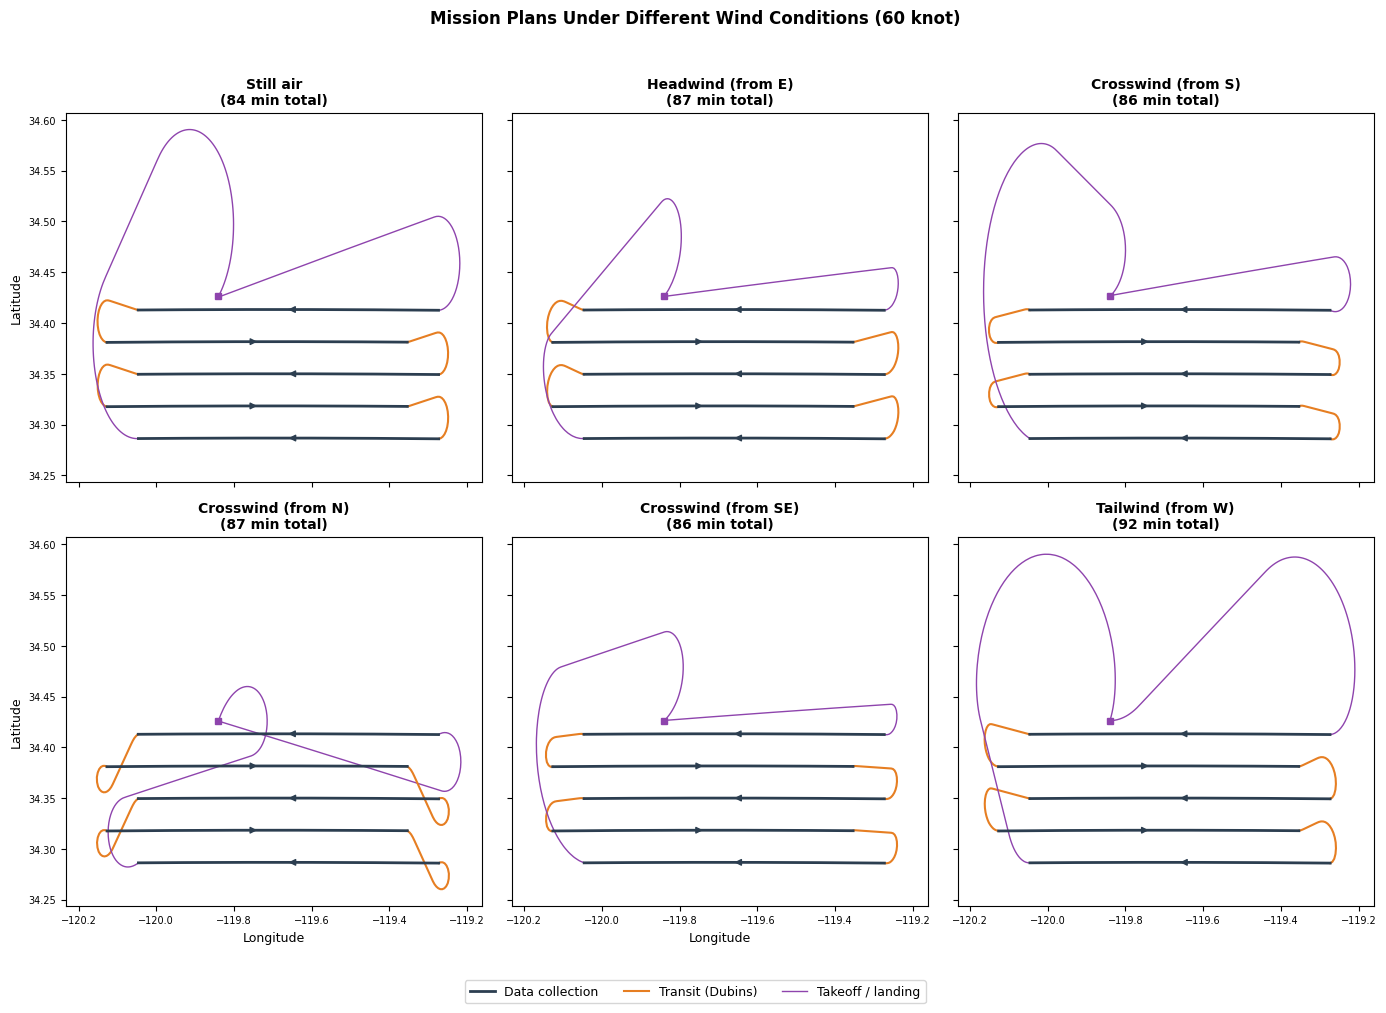

In [4]:
seg_colors = {
    "takeoff": "#8e44ad", "climb": "#8e44ad",
    "transit": "#e67e22",
    "flight_line": "#2c3e50",
    "descent": "#8e44ad", "approach": "#8e44ad",
}
seg_lw = {
    "takeoff": 1.0, "climb": 1.0,
    "transit": 1.5,
    "flight_line": 2.0,
    "descent": 1.0, "approach": 1.0,
}

fig, axes = plt.subplots(2, 3, figsize=(14, 10), sharex=True, sharey=True)

for ax, (name, plan) in zip(axes.flat, plans.items()):
    # Plot each segment
    for _, seg in plan.iterrows():
        geom = seg.geometry
        if geom is None or geom.is_empty:
            continue
        seg_type = seg["segment_type"]
        color = seg_colors.get(seg_type, "#bdc3c7")
        lw = seg_lw.get(seg_type, 1.0)
        xs, ys = geom.xy
        ax.plot(xs, ys, color=color, linewidth=lw,
                zorder=3 if seg_type == "flight_line" else 2)

        # Direction arrows on flight lines
        if seg_type == "flight_line":
            mid = len(xs) // 2
            if mid > 0:
                ax.annotate("", xy=(xs[mid], ys[mid]),
                            xytext=(xs[mid - 1], ys[mid - 1]),
                            arrowprops=dict(arrowstyle="-|>", color=color, lw=1),
                            zorder=5)

    # Airport marker
    ax.plot(departure.longitude, departure.latitude, "s",
            color="#8e44ad", markersize=5, zorder=6)

    total_min = plan["time_to_segment"].sum()
    ax.set_title(f"{name}\n({total_min:.0f} min total)", fontsize=10, fontweight="bold")
    ax.tick_params(labelsize=7)

axes[1, 0].set_xlabel("Longitude", fontsize=9)
axes[1, 1].set_xlabel("Longitude", fontsize=9)
axes[0, 0].set_ylabel("Latitude", fontsize=9)
axes[1, 0].set_ylabel("Latitude", fontsize=9)

# Shared legend
legend_elements = [
    plt.Line2D([0], [0], color="#2c3e50", lw=2, label="Data collection"),
    plt.Line2D([0], [0], color="#e67e22", lw=1.5, label="Transit (Dubins)"),
    plt.Line2D([0], [0], color="#8e44ad", lw=1, label="Takeoff / landing"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))

fig.suptitle(f"Mission Plans Under Different Wind Conditions ({wind_speed.to(ureg.knot):.0f})",
             fontsize=12, fontweight="bold")
fig.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

**Interpreting the maps:** The trochoidal distortion of transit arcs is clearly visible. In the crosswind cases, the arcs are pushed laterally, which could cause the aircraft to drift outside its assigned airspace during turns. In the tailwind case, the transit arcs are elongated in the downwind direction. These geometric distortions are not just visual -- they affect the actual airspace required for the mission and must be communicated to air traffic control. Note that all six plans maintain the same ground tracks for the data-collection segments; only the transit geometry and timing change.

## 4. Crab Angles and Segment Timing

**Crab angle explained:** When there is a crosswind, the pilot must point the aircraft's nose into the wind to maintain the desired ground track. The angle between the heading (where the nose points) and the ground track (where the aircraft actually goes) is the crab angle. A positive crab angle means the nose is pointed to the right of the ground track.

**Why this matters for remote sensing:** A 16-degree crab angle (as seen in the 60-kt crosswind case) rotates the sensor swath by 16 degrees. For a wide-swath instrument, this can cause gaps between adjacent flight lines or unexpected overlap patterns. It also means the along-track and cross-track directions in the imagery no longer align with the flight line azimuth, which complicates georeferencing and mosaicking.

In [5]:
import pandas as pd

for name, plan in plans.items():
    fl_rows = plan[plan["segment_type"] == "flight_line"].copy()
    if fl_rows.empty or "crab_angle_deg" not in fl_rows.columns:
        continue

    print(f"\n{name}:")
    print(f"  {'Segment':<25s}  {'Track':>6s}  {'Heading':>7s}  {'Crab':>6s}  "
          f"{'GS (kt)':>7s}  {'Time':>6s}  {'Tail (kt)':>9s}  {'Xwind (kt)':>10s}")
    print("  " + "-" * 90)
    for _, row in fl_rows.iterrows():
        print(f"  {row['segment_name']:<25s}  "
              f"{row.get('planned_track', 0):6.0f}  "
              f"{row.get('wind_corrected_heading', 0):7.0f}  "
              f"{row.get('crab_angle_deg', 0):+6.1f}  "
              f"{row.get('groundspeed_kts', 0):7.0f}  "
              f"{row['time_to_segment']:6.1f}  "
              f"{row.get('tailwind_kts', 0):+9.0f}  "
              f"{row.get('crosswind_kts', 0):+10.0f}")


Still air:
  Segment                     Track  Heading    Crab  GS (kt)    Time  Tail (kt)  Xwind (kt)
  ------------------------------------------------------------------------------------------
  SBC_L01_FL200                 270      270    -0.0      222    10.4         +0          +0
  SBC_L02_FL200                  90       90    -0.0      222    10.4         +0          +0
  SBC_L03_FL200                 270      270    -0.0      222    10.4         +0          +0
  SBC_L04_FL200                  90       90    -0.0      222    10.4         +0          +0
  SBC_L05_FL200                 270      270    -0.0      222    10.4         +0          +0

Headwind (from E):
  Segment                     Track  Heading    Crab  GS (kt)    Time  Tail (kt)  Xwind (kt)
  ------------------------------------------------------------------------------------------
  SBC_L01_FL200                 270      270    +0.1      282     8.2        +60          -0
  SBC_L02_FL200                  90   

**Interpreting the table:** Key observations:

- **Still air:** Heading equals ground track (crab angle is zero), groundspeed equals TAS (222 kt), and all legs take the same time.
- **Headwind (from E):** Eastbound legs slow to 162 kt groundspeed (headwind), westbound legs accelerate to 282 kt (tailwind). Crab angles are near zero because the wind is aligned with the flight lines.
- **Crosswind (from S):** Groundspeed drops to 214 kt on all legs (some airspeed is "used up" correcting for drift). Crab angles of +/-16 degrees mean the sensor swath is rotated significantly. This is the most important case for swath planning.
- **Tailwind (from W):** The mirror image of headwind. Westbound legs are slow (162 kt), eastbound legs are fast (282 kt).
- **Crosswind (from SE):** A combination of both effects -- crab angles of about 11 degrees plus asymmetric groundspeeds.

## 5. Crab Angle vs Wind Speed

**The physics:** When crosswind blows perpendicular to the desired ground track, the pilot must point the aircraft's nose into the wind. The crab angle is:

$$\theta_{\text{crab}} = \arcsin\!\left(\frac{V_{\text{crosswind}}}{V_{\text{TAS}}}\right)$$

This relationship is *nonlinear* -- crab angle grows slowly at low wind speeds but accelerates as crosswind approaches TAS. The plot below shows this for the B200 at FL200 (TAS ≈ 222 kt).

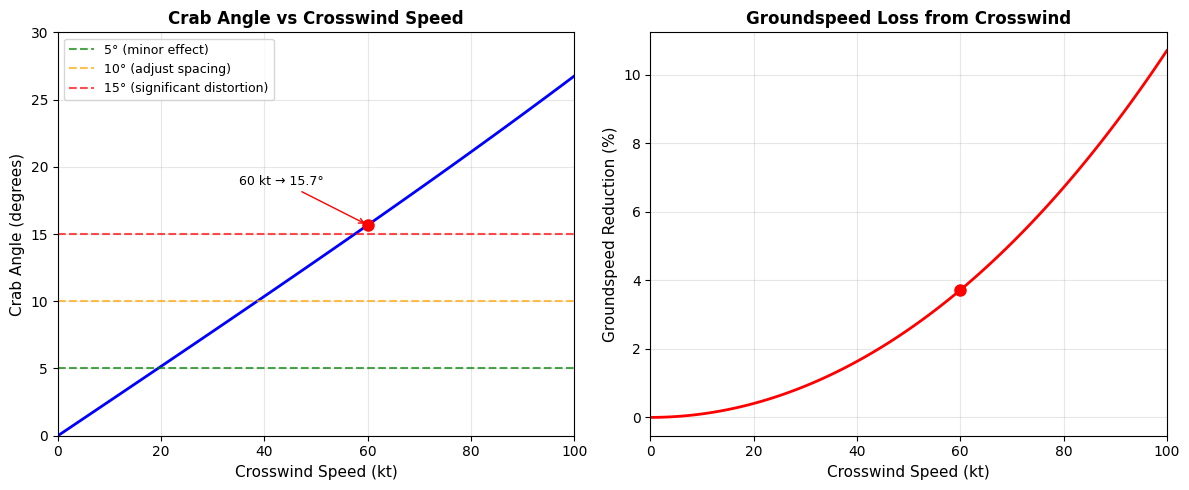


Reference thresholds for B200 at FL200 (TAS = 222 kt):
  Crosswind  10 kt → crab   2.6°, groundspeed 222 kt (100% of TAS)
  Crosswind  20 kt → crab   5.2°, groundspeed 221 kt (100% of TAS)
  Crosswind  30 kt → crab   7.8°, groundspeed 220 kt (99% of TAS)
  Crosswind  40 kt → crab  10.4°, groundspeed 219 kt (98% of TAS)
  Crosswind  50 kt → crab  13.0°, groundspeed 216 kt (97% of TAS)
  Crosswind  60 kt → crab  15.7°, groundspeed 214 kt (96% of TAS)
  Crosswind  80 kt → crab  21.1°, groundspeed 207 kt (93% of TAS)


In [6]:
tas_kt = cruise_speed.to(ureg.knot).magnitude  # ~222 kt

crosswind_speeds = np.arange(0, 101, 1)  # 0 to 100 kt
crab_angles = np.degrees(np.arcsin(np.clip(crosswind_speeds / tas_kt, -1, 1)))

# Also compute groundspeed reduction from crosswind
groundspeed = np.sqrt(tas_kt**2 - crosswind_speeds**2)
gs_reduction_pct = (1 - groundspeed / tas_kt) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: Crab angle vs crosswind
ax1.plot(crosswind_speeds, crab_angles, "b-", linewidth=2)
ax1.axhline(5, color="green", linestyle="--", alpha=0.7, label="5° (minor effect)")
ax1.axhline(10, color="orange", linestyle="--", alpha=0.7, label="10° (adjust spacing)")
ax1.axhline(15, color="red", linestyle="--", alpha=0.7, label="15° (significant distortion)")

# Mark the 60-kt case from our examples
crab_60 = np.degrees(np.arcsin(60 / tas_kt))
ax1.plot(60, crab_60, "ro", markersize=8, zorder=5)
ax1.annotate(f"60 kt → {crab_60:.1f}°", xy=(60, crab_60),
             xytext=(35, crab_60 + 3), fontsize=9,
             arrowprops=dict(arrowstyle="->", color="red"))

ax1.set_xlabel("Crosswind Speed (kt)", fontsize=11)
ax1.set_ylabel("Crab Angle (degrees)", fontsize=11)
ax1.set_title("Crab Angle vs Crosswind Speed", fontsize=12, fontweight="bold")
ax1.legend(fontsize=9)
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 30)
ax1.grid(True, alpha=0.3)

# Right: Groundspeed reduction
ax2.plot(crosswind_speeds, gs_reduction_pct, "r-", linewidth=2)
ax2.plot(60, (1 - np.sqrt(tas_kt**2 - 60**2) / tas_kt) * 100, "ro", markersize=8, zorder=5)
ax2.set_xlabel("Crosswind Speed (kt)", fontsize=11)
ax2.set_ylabel("Groundspeed Reduction (%)", fontsize=11)
ax2.set_title("Groundspeed Loss from Crosswind", fontsize=12, fontweight="bold")
ax2.set_xlim(0, 100)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print(f"\nReference thresholds for B200 at FL200 (TAS = {tas_kt:.0f} kt):")
for xw in [10, 20, 30, 40, 50, 60, 80]:
    ca = np.degrees(np.arcsin(xw / tas_kt))
    gs = np.sqrt(tas_kt**2 - xw**2)
    print(f"  Crosswind {xw:3d} kt → crab {ca:5.1f}°, groundspeed {gs:.0f} kt ({gs/tas_kt*100:.0f}% of TAS)")

**Interpreting the plots:** The left panel shows that crab angle grows nonlinearly with crosswind speed. Below about 30 kt of crosswind (~14% of TAS), the crab angle stays under 8° -- generally acceptable for most sensors. At 60 kt crosswind (our example case), the crab angle reaches ~16°, which is large enough to cause significant swath rotation. The right panel shows the corresponding groundspeed reduction: at 60 kt crosswind, groundspeed drops by about 4%, but at 80 kt crosswind it drops by over 7%. The groundspeed loss is modest at typical crosswind speeds, but the crab angle effect on sensor geometry is the real concern.

## 6. Swath Distortion from Crab Angle

**The problem:** A pushbroom sensor images perpendicular to the aircraft's *heading*, not perpendicular to the *ground track*. In still air these are the same, but in crosswind the crab angle rotates the sensor's field of view. The result: the swath footprint on the ground is rotated relative to the planned ground track, creating a parallelogram-shaped coverage area instead of a rectangle.

Below we generate swath polygons for a single flight line under three conditions:
1. **No wind (track-aligned):** The ideal case -- swath is perpendicular to the ground track
2. **60 kt crosswind (crabbed):** The swath is rotated by the crab angle (~16°)
3. **30 kt crosswind (crabbed):** A moderate case (~8° crab)

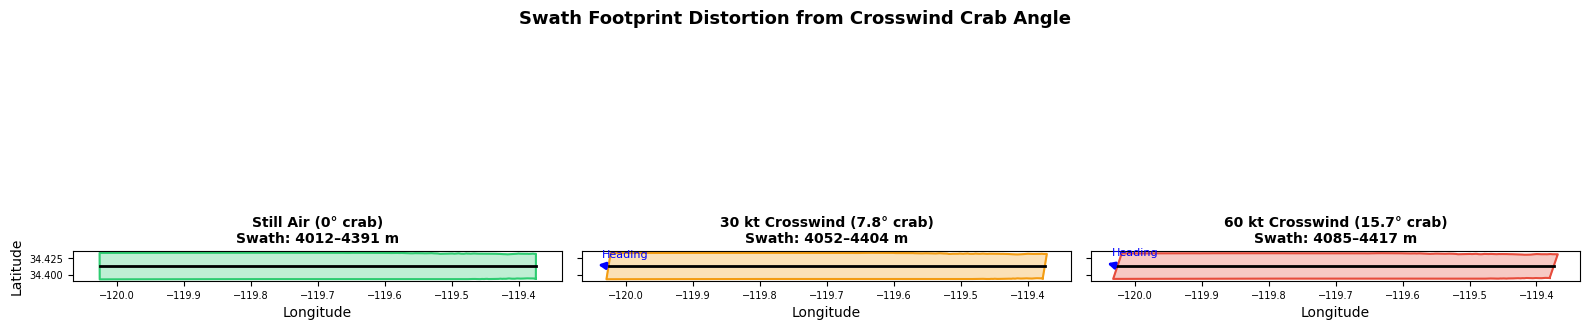

In [7]:
from shapely.geometry import Polygon as ShapelyPolygon

# Use the first flight line for demonstration
demo_fl = flight_lines[0]

# Crab angles for three crosswind cases
crab_0 = 0.0   # still air
crab_30 = np.degrees(np.arcsin(30 / tas_kt))   # ~7.8°
crab_60 = np.degrees(np.arcsin(60 / tas_kt))   # ~15.7°

# Generate swath polygons
swath_ideal = generate_swath_polygon(demo_fl, sensor, heading_mode="track")
swath_30kt = generate_swath_polygon(demo_fl, sensor, heading_mode="crabbed", crab_angle_deg=crab_30)
swath_60kt = generate_swath_polygon(demo_fl, sensor, heading_mode="crabbed", crab_angle_deg=crab_60)

# Compute swath widths for each
widths_ideal = calculate_swath_widths(swath_ideal)
widths_30kt = calculate_swath_widths(swath_30kt)
widths_60kt = calculate_swath_widths(swath_60kt)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

cases = [
    ("Still Air (0° crab)", swath_ideal, widths_ideal, "#2ecc71", crab_0),
    (f"30 kt Crosswind ({crab_30:.1f}° crab)", swath_30kt, widths_30kt, "#f39c12", crab_30),
    (f"60 kt Crosswind ({crab_60:.1f}° crab)", swath_60kt, widths_60kt, "#e74c3c", crab_60),
]

for ax, (label, swath, widths, color, crab) in zip(axes, cases):
    # Plot the swath polygon
    xs, ys = swath.exterior.xy
    ax.fill(xs, ys, alpha=0.3, color=color)
    ax.plot(xs, ys, color=color, linewidth=1.5)

    # Plot the flight line
    geom = demo_fl.geometry
    fx, fy = geom.xy
    ax.plot(fx, fy, "k-", linewidth=2, label="Ground track")

    # Show heading direction with an arrow at the midpoint
    if abs(crab) > 0.5:
        mid_idx = len(fx) // 2
        mx, my = fx[mid_idx], fy[mid_idx]
        heading_rad = np.radians(demo_fl.az12.magnitude + crab)
        arrow_len = 0.02
        dx = arrow_len * np.sin(heading_rad)
        dy = arrow_len * np.cos(heading_rad)
        ax.annotate("", xy=(mx + dx, my + dy), xytext=(mx, my),
                    arrowprops=dict(arrowstyle="-|>", color="blue", lw=2))
        ax.annotate("Heading", xy=(mx + dx, my + dy), fontsize=8, color="blue",
                    xytext=(5, 5), textcoords="offset points")

    ax.set_title(f"{label}\nSwath: {widths['min_width']:.0f}–{widths['max_width']:.0f} m",
                 fontsize=10, fontweight="bold")
    ax.tick_params(labelsize=7)
    ax.set_aspect("equal")

axes[0].set_ylabel("Latitude", fontsize=10)
for ax in axes:
    ax.set_xlabel("Longitude", fontsize=10)

fig.suptitle("Swath Footprint Distortion from Crosswind Crab Angle",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

**Interpreting the swath plots:** In still air, the swath is a clean rectangle aligned with the ground track. With a 30 kt crosswind (~8° crab), the swath rotates slightly, creating a parallelogram shape -- the edges shift north/south relative to the flight line. At 60 kt crosswind (~16° crab), the rotation is pronounced. The key insight: the swath *width* measured perpendicular to the ground track is reduced by the cosine of the crab angle, while the sensor's cross-track extent now has a component *along* the flight line direction. This means adjacent flight lines planned for still-air overlap may have **gaps** in actual coverage.

## 7. Overlap Gaps: What Happens When Wind Is Ignored

**The critical question:** If you plan flight line spacing assuming still-air (track-perpendicular swaths), but the aircraft actually crabs into a crosswind, do you still get full coverage?

Below we generate swath polygons for **all five flight lines** under two scenarios:
1. **Planned coverage** (track-aligned swaths, as if no wind)
2. **Actual coverage** (crabbed swaths under 60 kt crosswind)

We then compute the union of all swaths in each case and compare the total area, looking for gaps between adjacent lines.

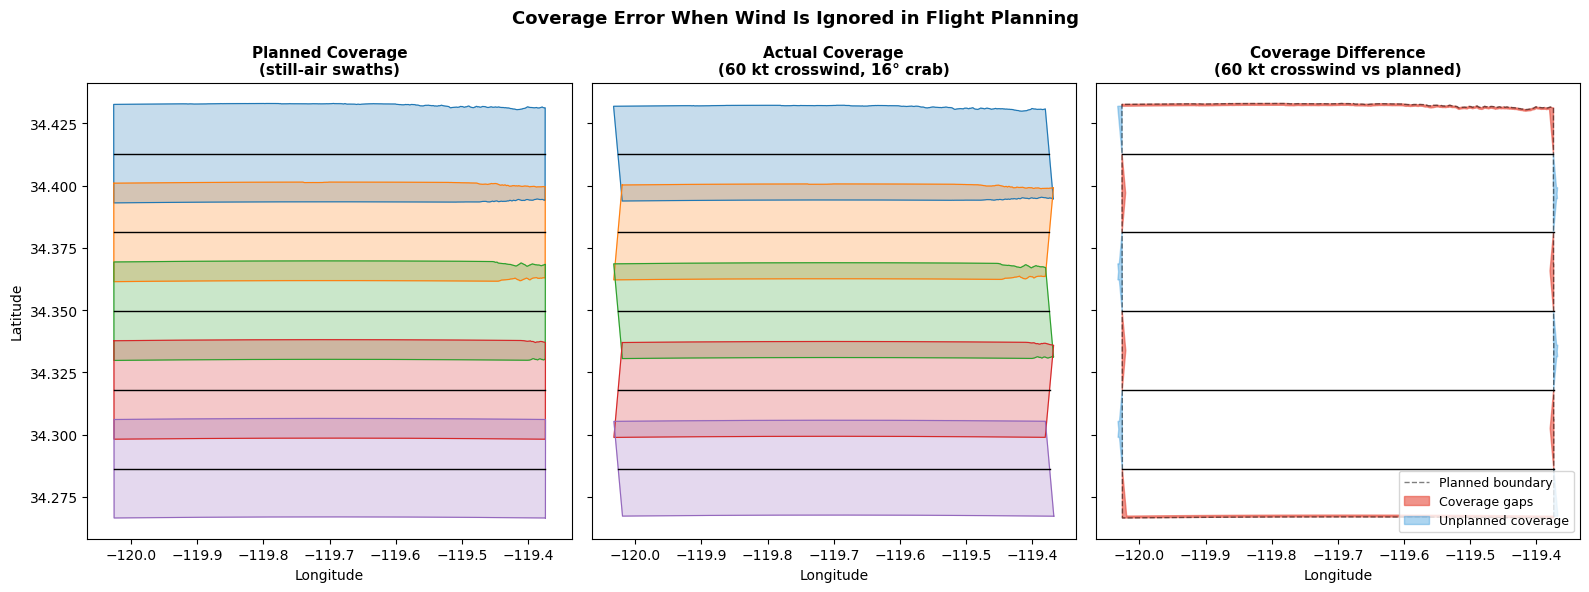

Coverage comparison (60 kt crosswind from south):
  Planned coverage area:    1103.9 km²
  Actual coverage area:     1094.5 km²
  Gaps (planned but missed):14.27 km² (1.3%)
  Extra (unplanned):        4.91 km² (0.4%)

For comparison, 30 kt crosswind:
  Gaps:                     4.67 km² (0.4%)


In [8]:
from shapely.ops import unary_union

# Generate swath polygons for all flight lines: planned (no crab) vs actual (60 kt crosswind)
swaths_planned = []
swaths_actual_60 = []
swaths_actual_30 = []

for fl in flight_lines:
    # Planned: track-aligned (still air assumption)
    sp = generate_swath_polygon(fl, sensor, heading_mode="track")
    swaths_planned.append(sp)

    # Actual: crabbed at 60 kt crosswind (sign depends on flight direction)
    # Crosswind from south (180°) on an east-west line:
    # Westbound (az=270): crab is negative (nose points south of track)
    # Eastbound (az=90): crab is positive (nose points south of track)
    az = fl.az12.magnitude
    crab = crab_60 if az < 180 else -crab_60
    sa60 = generate_swath_polygon(fl, sensor, heading_mode="crabbed", crab_angle_deg=crab)
    swaths_actual_60.append(sa60)

    crab_m = crab_30 if az < 180 else -crab_30
    sa30 = generate_swath_polygon(fl, sensor, heading_mode="crabbed", crab_angle_deg=crab_m)
    swaths_actual_30.append(sa30)

# Compute coverage unions
union_planned = unary_union(swaths_planned)
union_actual_60 = unary_union(swaths_actual_60)
union_actual_30 = unary_union(swaths_actual_30)

# Find gaps: area in planned but not in actual
gaps_60 = union_planned.difference(union_actual_60)
gaps_30 = union_planned.difference(union_actual_30)

# Find extra: area in actual but not in planned
extra_60 = union_actual_60.difference(union_planned)
extra_30 = union_actual_30.difference(union_planned)

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharex=True, sharey=True)

# Panel 1: Planned coverage
ax = axes[0]
for i, sp in enumerate(swaths_planned):
    xs, ys = sp.exterior.xy
    ax.fill(xs, ys, alpha=0.25, color=f"C{i}")
    ax.plot(xs, ys, color=f"C{i}", linewidth=0.8)
for fl in flight_lines:
    fx, fy = fl.geometry.xy
    ax.plot(fx, fy, "k-", linewidth=1)
ax.set_title("Planned Coverage\n(still-air swaths)", fontsize=11, fontweight="bold")
ax.set_ylabel("Latitude", fontsize=10)
ax.set_xlabel("Longitude", fontsize=10)

# Panel 2: Actual coverage at 60 kt crosswind
ax = axes[1]
for i, sa in enumerate(swaths_actual_60):
    xs, ys = sa.exterior.xy
    ax.fill(xs, ys, alpha=0.25, color=f"C{i}")
    ax.plot(xs, ys, color=f"C{i}", linewidth=0.8)
for fl in flight_lines:
    fx, fy = fl.geometry.xy
    ax.plot(fx, fy, "k-", linewidth=1)
ax.set_title(f"Actual Coverage\n(60 kt crosswind, {crab_60:.0f}° crab)", fontsize=11, fontweight="bold")
ax.set_xlabel("Longitude", fontsize=10)

# Panel 3: Gaps and extra coverage
ax = axes[2]
# Show planned footprint outline
if hasattr(union_planned, 'exterior'):
    xs, ys = union_planned.exterior.xy
    ax.plot(xs, ys, "k--", linewidth=1, alpha=0.5, label="Planned boundary")

# Show gaps (planned but not covered) in red
if not gaps_60.is_empty:
    if gaps_60.geom_type == "MultiPolygon":
        for g in gaps_60.geoms:
            gx, gy = g.exterior.xy
            ax.fill(gx, gy, alpha=0.6, color="#e74c3c")
    elif gaps_60.geom_type == "Polygon":
        gx, gy = gaps_60.exterior.xy
        ax.fill(gx, gy, alpha=0.6, color="#e74c3c")
    ax.fill([], [], alpha=0.6, color="#e74c3c", label="Coverage gaps")

# Show extra coverage (not planned but covered) in blue
if not extra_60.is_empty:
    if extra_60.geom_type == "MultiPolygon":
        for g in extra_60.geoms:
            ex, ey = g.exterior.xy
            ax.fill(ex, ey, alpha=0.4, color="#3498db")
    elif extra_60.geom_type == "Polygon":
        ex, ey = extra_60.exterior.xy
        ax.fill(ex, ey, alpha=0.4, color="#3498db")
    ax.fill([], [], alpha=0.4, color="#3498db", label="Unplanned coverage")

for fl in flight_lines:
    fx, fy = fl.geometry.xy
    ax.plot(fx, fy, "k-", linewidth=1)

ax.set_title("Coverage Difference\n(60 kt crosswind vs planned)", fontsize=11, fontweight="bold")
ax.set_xlabel("Longitude", fontsize=10)
ax.legend(fontsize=9, loc="lower right")

fig.suptitle("Coverage Error When Wind Is Ignored in Flight Planning",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

# Quantitative summary
def area_km2(poly):
    """Approximate area in km² using a local projection."""
    if poly.is_empty:
        return 0.0
    gdf = gpd.GeoDataFrame(geometry=[poly], crs="EPSG:4326")
    centroid = poly.centroid
    utm_zone = int((centroid.x + 180) / 6) + 1
    epsg = 32600 + utm_zone if centroid.y >= 0 else 32700 + utm_zone
    return gdf.to_crs(epsg=epsg).area.iloc[0] / 1e6

planned_area = area_km2(union_planned)
actual_60_area = area_km2(union_actual_60)
gap_60_area = area_km2(gaps_60)
extra_60_area = area_km2(extra_60)
gap_30_area = area_km2(gaps_30)

print(f"Coverage comparison (60 kt crosswind from south):")
print(f"  Planned coverage area:    {planned_area:.1f} km²")
print(f"  Actual coverage area:     {actual_60_area:.1f} km²")
print(f"  Gaps (planned but missed):{gap_60_area:.2f} km² ({gap_60_area/planned_area*100:.1f}%)")
print(f"  Extra (unplanned):        {extra_60_area:.2f} km² ({extra_60_area/planned_area*100:.1f}%)")
print(f"\nFor comparison, 30 kt crosswind:")
print(f"  Gaps:                     {gap_30_area:.2f} km² ({gap_30_area/planned_area*100:.1f}%)")

**Interpreting the coverage analysis:** The three panels tell a clear story:

- **Left (planned):** Rectangular swaths with the designed 20% overlap between adjacent lines. Full coverage of the study area.
- **Center (actual):** The crabbed swaths are rotated parallelograms. The swath still covers roughly the same total area, but it has shifted laterally -- coverage extends beyond the planned boundary on one side while leaving gaps on the other.
- **Right (difference):** Red areas are **coverage gaps** -- parts of the planned study area that are *not* imaged due to swath rotation. Blue areas are **unplanned coverage** -- areas outside the planned boundary that get imaged instead. The swath rotation effectively shifts coverage sideways without changing its total area.

**The operational implication:** If your science requires complete coverage of a specific study area, you must either (a) plan additional flight lines to compensate for the expected crab angle, or (b) increase overlap margins to absorb the worst-case swath rotation. The `generate_swath_polygon(..., heading_mode="crabbed")` function lets you model this during planning.

## 8. Wind Direction Sensitivity -- Polar Plot

**The problem:** In the sections above, we tested a few specific wind directions. But which wind direction is the *worst case* for your mission? The polar plot below sweeps wind direction through the full 360 degrees and shows total mission time at each angle. This reveals the full sensitivity pattern and helps identify the most and least favorable wind directions.

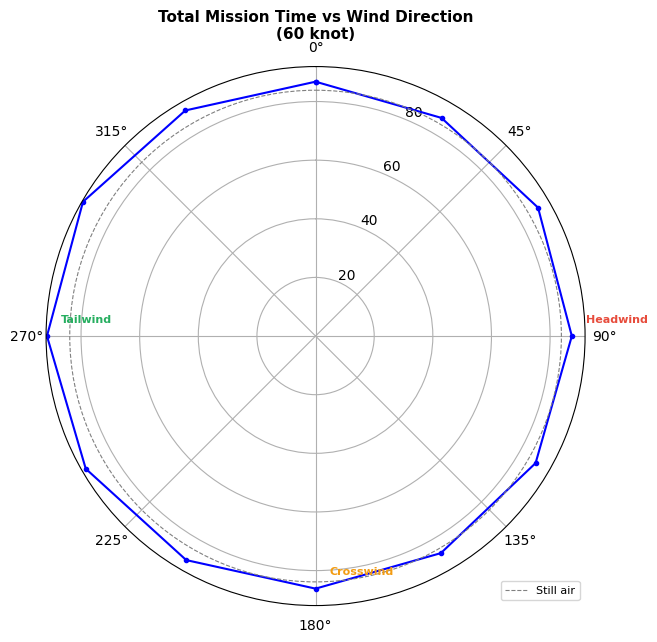


Still air: 84 min
Min time:  85 min (wind from 150°)
Max time:  92 min (wind from 270°)
Range:     6 min


In [9]:
directions = np.arange(0, 360, 30)
times = []

for d in directions:
    wf = ConstantWindField(wind_speed=wind_speed, wind_from_deg=float(d))
    plan = compute_flight_plan(
        aircraft=aircraft, flight_sequence=flight_lines,
        takeoff_airport=departure, return_airport=departure,
        wind_source=wf,
    )
    times.append(plan["time_to_segment"].sum())

still_time = plans["Still air"]["time_to_segment"].sum()

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={"projection": "polar"})
theta = np.radians(directions)
# Close the loop
theta_closed = np.append(theta, theta[0])
times_closed = np.append(times, times[0])

ax.plot(theta_closed, times_closed, "b-o", markersize=3, linewidth=1.5)
ax.axhline(still_time, color="gray", linestyle="--", linewidth=0.8, label="Still air")
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_title(f"Total Mission Time vs Wind Direction\n({wind_speed.to(ureg.knot):.0f})",
             fontsize=11, fontweight="bold", pad=20)

# Mark the three key directions
for angle, label, color in [(90, "Headwind", "#e74c3c"),
                             (180, "Crosswind", "#f39c12"),
                             (270, "Tailwind", "#27ae60")]:
    ax.annotate(label, xy=(np.radians(angle), times[directions.tolist().index(angle)]),
                fontsize=8, color=color, fontweight="bold",
                xytext=(10, 10), textcoords="offset points")

ax.legend(loc="lower right", fontsize=8)
plt.show()

print(f"\nStill air: {still_time:.0f} min")
print(f"Min time:  {min(times):.0f} min (wind from {directions[np.argmin(times)]}°)")
print(f"Max time:  {max(times):.0f} min (wind from {directions[np.argmax(times)]}°)")
print(f"Range:     {max(times) - min(times):.0f} min")

**Interpreting the plot:** The polar plot reveals that the worst-case wind direction for this east-west mission is wind from the west (270 degrees, a tailwind on the majority of legs), not from the east as one might expect. This is because there are 3 westbound legs and only 2 eastbound legs -- so a westerly wind creates a headwind on 3 legs and a tailwind on only 2. The best-case direction is wind from the east (90 degrees) for the same reason -- it provides tailwind on 3 of 5 legs. The roughly 8-minute range between best and worst cases represents about 10% of total mission time, which is significant for fuel planning and scheduling.

## Operational Takeaways

- **Wind-aware planning is necessary when wind exceeds ~15-20% of TAS.** At FL200 with a B200 (222 kt TAS), this threshold is about 35-45 kt. Below that, still-air plans give adequate timing estimates.
- **Crosswind is the primary concern for sensor geometry.** Even when total timing barely changes, a crosswind creates crab angles that rotate the sensor swath. For wide-swath instruments, crab angles above 5-10 degrees require adjusted flight line spacing to avoid gaps.
- **The worst-case wind direction depends on your line pattern.** For alternating east-west lines with unequal counts, the worst direction is a headwind on the majority of legs. Always run the polar sensitivity analysis when planning a campaign.
- **Trochoidal transit arcs expand the airspace footprint.** In strong winds, Dubins turns drift significantly downwind, which must be accounted for in airspace reservations and ATC coordination.
- **Heading and ground track are different in wind.** Always distinguish between these in planning documents. The ground track is what determines sensor coverage; the heading is what the pilot flies. HyPlan reports both.
- **Individual leg timing can vary by 40% or more** between headwind and tailwind legs at 60 kt, even when total mission time changes by only 5-10%. This matters for time-sensitive targets or coordinated multi-aircraft operations.

## Summary

| Wind condition | Effect on flight lines | Effect on transits | Effect on timing |
|---|---|---|---|
| **Headwind** | Groundspeed decreases, legs take longer | Trochoidal arcs drift downwind | Total time increases |
| **Crosswind** | Crab angle rotates sensor FOV relative to ground track | Arcs distorted perpendicular to flight direction | Moderate time increase from reduced ground speed |
| **Tailwind** | Groundspeed increases, legs are faster | Arcs drift downwind (same direction as flight) | Total time may increase if majority of legs face headwind |